# Breast Cancer Prediction Pipeline

This notebook implements the main pipeline for breast cancer classification using RNA-Seq data. It includes data loading and preprocessing, statistical feature selection (ANOVA F-test), dimensionality reduction (PCA), and classification using a Random Forest model.

## Setup and Configuration

This step sets up the required libraries and defines the folder structure used in this notebook. The data is organized into four main folders under `data/`:
- `raw/`: Raw downloaded files (e.g., GTEx `.gct`, GDC `.tsv`).
- `initial/`: Processed raw files (e.g., merged and transposed).
- `interim/`: Feature-selected or partially transformed files.
- `processed/`: Final model-ready inputs (e.g., PCA-reduced features).

In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import shutil
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [2]:
# Define data folder structure
DATA_DIR = "data"

RAW_GDC_DIR = os.path.join(DATA_DIR, "raw_gdc_data")
RAW_GTX_DIR = os.path.join(DATA_DIR, "raw_gtx_data")

INITIAL_DIR = os.path.join(DATA_DIR, "initial")
INTERIM_DIR = os.path.join(DATA_DIR, "interim")

MAIN_PIPLINE_DIR = "pipeline_01"

MODELS_DIR = os.path.join(MAIN_PIPLINE_DIR, "models")
REPORTS_DIR = os.path.join(MAIN_PIPLINE_DIR, "reports")

In [3]:
# Create directories if they don't exist
os.makedirs(MAIN_PIPLINE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

### Step 1: Statistical Feature Selection using ANOVA F-test

This step applies a univariate statistical method — the ANOVA F-test — to select the most informative gene features for classification. It is a standard approach for high-dimensional data such as RNA-Seq, where the number of features (genes) far exceeds the number of samples.

This step includes:
1. **Loads**:
   - The combined feature matrix from `data/interim/preprocessed_data_features.csv`
   - The label vector from `data/interim/preprocessed_data_labels.csv`
2. Applies **ANOVA F-test** using `SelectKBest` from `scikit-learn` to select the top 1000 gene features that show the most variation between the cancer and non-cancer classes.
3. Saves the reduced feature matrix for downstream use.

##### Output:
- `selected_features.csv` (in `data/interim/`): A reduced feature matrix with shape (samples × 1000)

This step dramatically reduces the feature space from ~60,000 genes to 1000, making subsequent modeling steps more efficient and less prone to overfitting.


In [4]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

def remove_constant_features(features):
    """Remove constant features from the dataset."""
    selector = VarianceThreshold()
    return selector.fit_transform(features), selector.get_support(indices=True)

def statistical_feature_selection(features_file, labels_file, output_file, k=1000):
    # Load preprocessed features and labels
    features = pd.read_csv(features_file)
    labels = pd.read_csv(labels_file)

    # Handle NaN values by imputing with the mean
    imputer = SimpleImputer(strategy='mean')
    features_imputed = imputer.fit_transform(features)

    # Remove constant features
    features_imputed, selected_indices = remove_constant_features(features_imputed)
    feature_names = features.columns[selected_indices]

    # Perform feature selection
    selector = SelectKBest(f_classif, k=k)
    selected_features = selector.fit_transform(features_imputed, labels['label'])

    # Get selected feature names
    feature_names = feature_names[selector.get_support()]
    selected_features_df = pd.DataFrame(selected_features, columns=feature_names)
    
    # Save the selected features to the output file
    selected_features_df.to_csv(output_file, index=False)

    print("Statistical Feature Selection Complete")
    print("Shape of selected features:", selected_features_df.shape)


In [5]:
features_file = os.path.join(INTERIM_DIR, 'training_data_features.csv')
labels_file = os.path.join(INTERIM_DIR,'training_data_labels.csv')

output_file = os.path.join(MAIN_PIPLINE_DIR, 'training_data_selected_features.csv')

statistical_feature_selection(features_file, labels_file, output_file)

Statistical Feature Selection Complete
Shape of selected features: (2000, 1000)


In [6]:
label_file_in_interim = os.path.join(INTERIM_DIR, 'training_data_labels.csv')
label_file_in_pipeline = os.path.join(MAIN_PIPLINE_DIR, 'training_data_labels.csv')

# Copy the label file into the "processed" folder 
shutil.copyfile(label_file_in_interim, label_file_in_pipeline)

'pipeline_01/training_data_labels.csv'

### Step 2: Dimensionality Reduction using PCA

After statistical feature selection, this step applies Principal Component Analysis (PCA) to further reduce the dimensionality of the data. PCA projects the 1000 selected gene features into a lower-dimensional space while preserving as much variance as possible.

This step includes:
1. **Loads**:
   - The 1000-gene feature matrix from `data/interim/selected_features.csv`
2. Applies **PCA** to reduce the feature space to 50 principal components.
3. Transforms the dataset into the reduced space and saves it.

##### Output:
- `pca_reduced_features.csv` (in `data/processed/`): A feature matrix with shape (samples × 50), ready for training classifiers.

PCA helps compress the dataset, reduce noise, and improve the stability and performance of machine learning models in high-dimensional settings like genomics.


In [7]:
def dimensionality_reduction(selected_features_file, output_file, n_components=50):
    # Load selected features
    selected_features = pd.read_csv(selected_features_file)

    # Perform PCA
    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(selected_features)

    # Create a DataFrame with reduced features
    reduced_features_df = pd.DataFrame(reduced_features, columns=[f'PC{i+1}' for i in range(n_components)])
    
    # Save the reduced features to the output file
    reduced_features_df.to_csv(output_file, index=False)

    print("Dimensionality Reduction Complete")
    print("Shape of reduced features:", reduced_features_df.shape)

In [8]:
n_components = 50
selected_features_file = os.path.join(MAIN_PIPLINE_DIR, 'training_data_selected_features.csv')
output_file = os.path.join(MAIN_PIPLINE_DIR, 'training_data_reduced_features.csv')

dimensionality_reduction(selected_features_file, output_file, n_components)

Dimensionality Reduction Complete
Shape of reduced features: (2000, 50)


Create the following files the `processed` folder:

These data sets contains training data with 50 PCs, which will be used for model training and cross validation:

- `dataset.csv`: a complete training dataset of both cancer (1000 samples) and non-cancer (1000 samples) with their labels
- `benign.csv`: only non-cancer data (1000 samples) with their labels
- `cancer.csv`: only cancer data (1000 samples) with their labels

In [9]:
labels_file_path = os.path.join(MAIN_PIPLINE_DIR, 'training_data_labels.csv')
features_file_path = os.path.join(MAIN_PIPLINE_DIR, 'training_data_reduced_features.csv')

labels_df = pd.read_csv(labels_file_path)
features_df = pd.read_csv(features_file_path)

dataset_df = pd.concat([features_df, labels_df], axis=1)
dataset_df.to_csv(os.path.join(MAIN_PIPLINE_DIR, 'dataset.csv'), index=False)

benign_dataset = dataset_df[dataset_df['label'] == 0]
benign_dataset.to_csv(os.path.join(MAIN_PIPLINE_DIR, 'benign.csv'), index=False)

cancer_dataset = dataset_df[dataset_df['label'] == 1]
cancer_dataset.to_csv(os.path.join(MAIN_PIPLINE_DIR, 'cancer.csv'), index=False)

### Step 3: Classification with Random Forest and Evaluation

This step trains a machine learning classifier to distinguish between cancer and non-cancer samples using the PCA-reduced feature matrix.

A **Random Forest** classifier is used due to its robustness, interpretability, and suitability for high-dimensional biological data. Evaluation is done using **5-fold Stratified Cross-Validation** to ensure balanced class representation in each fold.

This step includes:
1. **Loads**:
   - PCA-reduced feature matrix from `data/processed/pca_reduced_features.csv`
   - Corresponding labels from `data/interim/preprocessed_data_labels.csv`
2. Performs **5-fold Stratified Cross-Validation**, training and testing the Random Forest model on different splits.
3. Computes and stores key performance metrics:
   - Accuracy
   - Precision
   - Recall
   - F1-score

##### Output:
- A printed performance summary for each fold.
- Optionally: confusion matrices and average metric summaries.

This step provides a robust estimate of the model’s generalization performance on unseen data.


In [ ]:
def dual_print(file_path, *args, **kwargs):
    mode = kwargs.get('mode', 'a')
    message = " ".join(map(str, args))
    print(message)
    with open(file_path, mode) as file:
        file.write(message + '\n')

In [ ]:
def cross_validate_model(features_file, labels_file, model_file_prefix, report_file, num_splits=5, perm=False, n_permutations=500):
    
    # Load data
    X = pd.read_csv(features_file)
    y = pd.read_csv(labels_file).values.ravel()

    # Stratified K-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=45)
    accuracies, precisions, recalls, f1_scores , aucs, specificities = [], [], [], [], [], []
    confusion_matrices = []

    fig_cm = plt.figure(figsize=(12, 6), dpi=300, constrained_layout=False)
    gs = gridspec.GridSpec(2, 6, figure=fig_cm, wspace=3, hspace=0.5)

    model_number = 0
    for train_index, test_index in skf.split(X, y):
        
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model_number += 1
        
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)

        # Save the model
        model_file = model_file_prefix + str(model_number) + '.pkl'
        with open(model_file, 'wb') as f:
            pickle.dump(model, f)
            
        y_pred = model.predict(X_test)

        cur_acc = accuracy_score(y_test, y_pred)
        accuracies.append(cur_acc)

        cur_pre = precision_score(y_test, y_pred, zero_division=1)
        precisions.append(cur_pre)

        cur_rec = recall_score(y_test, y_pred, zero_division=1)
        recalls.append(cur_rec)

        cur_f1 = f1_score(y_test, y_pred, zero_division=1)
        f1_scores.append(cur_f1)

        # AUC (Area Under Curve)
        y_proba = model.predict_proba(X_test)[:, 1]
        cur_auc = roc_auc_score(y_test, y_proba)
        aucs.append(cur_auc)

        # Specificity = TN / (TN + FP)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        cur_spe = tn / (tn + fp)
        specificities.append(cur_spe)

        # Save confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices.append(cm)

        # Draw confusion matrices in one plot
        i = model_number - 1
        if i < 3:
            ax = plt.subplot(gs[0, 2 * i:2 * i + 2])
        else:
            ax = plt.subplot(gs[1, 2 * i - 5:2 * i + 2 - 5])
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Fold {model_number}', fontsize=9, fontweight="bold")
        ax.set_xlabel('Prediction', fontsize = 8, fontweight="bold")
        ax.set_ylabel('Actual', fontsize = 8, fontweight="bold")
        ax.set_xticklabels(['Benign', 'Cancer'], fontsize=7, rotation=0)
        ax.set_yticklabels(['Benign', 'Cancer'], fontsize=7, rotation=90)
    
    # Compute averages
    avg_accuracy = sum(accuracies) / num_splits
    avg_precision = sum(precisions) / num_splits
    avg_recall = sum(recalls) / num_splits
    avg_f1_score = sum(f1_scores) / num_splits
    avg_auc = sum(aucs) / num_splits
    avg_specificity = sum(specificities) / num_splits

    # Log Cross-Validation Results
    dual_print(report_file, f"Cross-Validation Results:", mode='w')
    dual_print(report_file, f"  Accuracy: {avg_accuracy:.4f}")
    dual_print(report_file, f"  Precision: {avg_precision:.4f}")
    dual_print(report_file, f"  Recall: {avg_recall:.4f}")
    dual_print(report_file, f"  F1 Score: {avg_f1_score:.4f}")
    dual_print(report_file, f"  AUC: {avg_auc:.4f}")
    dual_print(report_file, f"  Specificity: {avg_specificity:.4f}")

    # Plot ROC curve for the last fold in cross-validation (or any specific fold you choose)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    fig_roc = plt.figure(figsize=(6, 6), dpi=300)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    fig_cm.savefig(f"{os.path.join(REPORTS_DIR, 'rfc_model_5F_CV_')}_cf.png")
    fig_roc.savefig(f"{os.path.join(REPORTS_DIR, 'rfc_model_5F_CV_')}_roc.png")


    # Save final trained model
    with open(f"{model_file_prefix}_random_forest.pkl", "wb") as model_file:
        pickle.dump(model, model_file)

    if perm == True:
        # Perform Permutation Test
        score, permutation_scores, p_value = permutation_test_score(
            model, X, y, scoring="accuracy", cv=skf, n_permutations=n_permutations, random_state=42)

        # Log Permutation Test Results
        dual_print(report_file, f"Permutation Test Results:")
        dual_print(report_file, f"  Original Model Accuracy: {score:.4f}")
        dual_print(report_file, f"  Mean Permuted Accuracy: {permutation_scores.mean():.4f}")
        dual_print(report_file, f"  p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            dual_print(report_file, "  The model significantly outperforms random chance (p < 0.05).")
        else:
            dual_print(report_file, "  The model's performance is not significantly better than random.")

Cross-Validation Results:
Cross-Validation Results:
  Accuracy: 0.9960
  Precision: 0.9940
  Recall: 0.9980
  F1 Score: 0.9960
  AUC: 0.9999
  Specificity: 0.9940


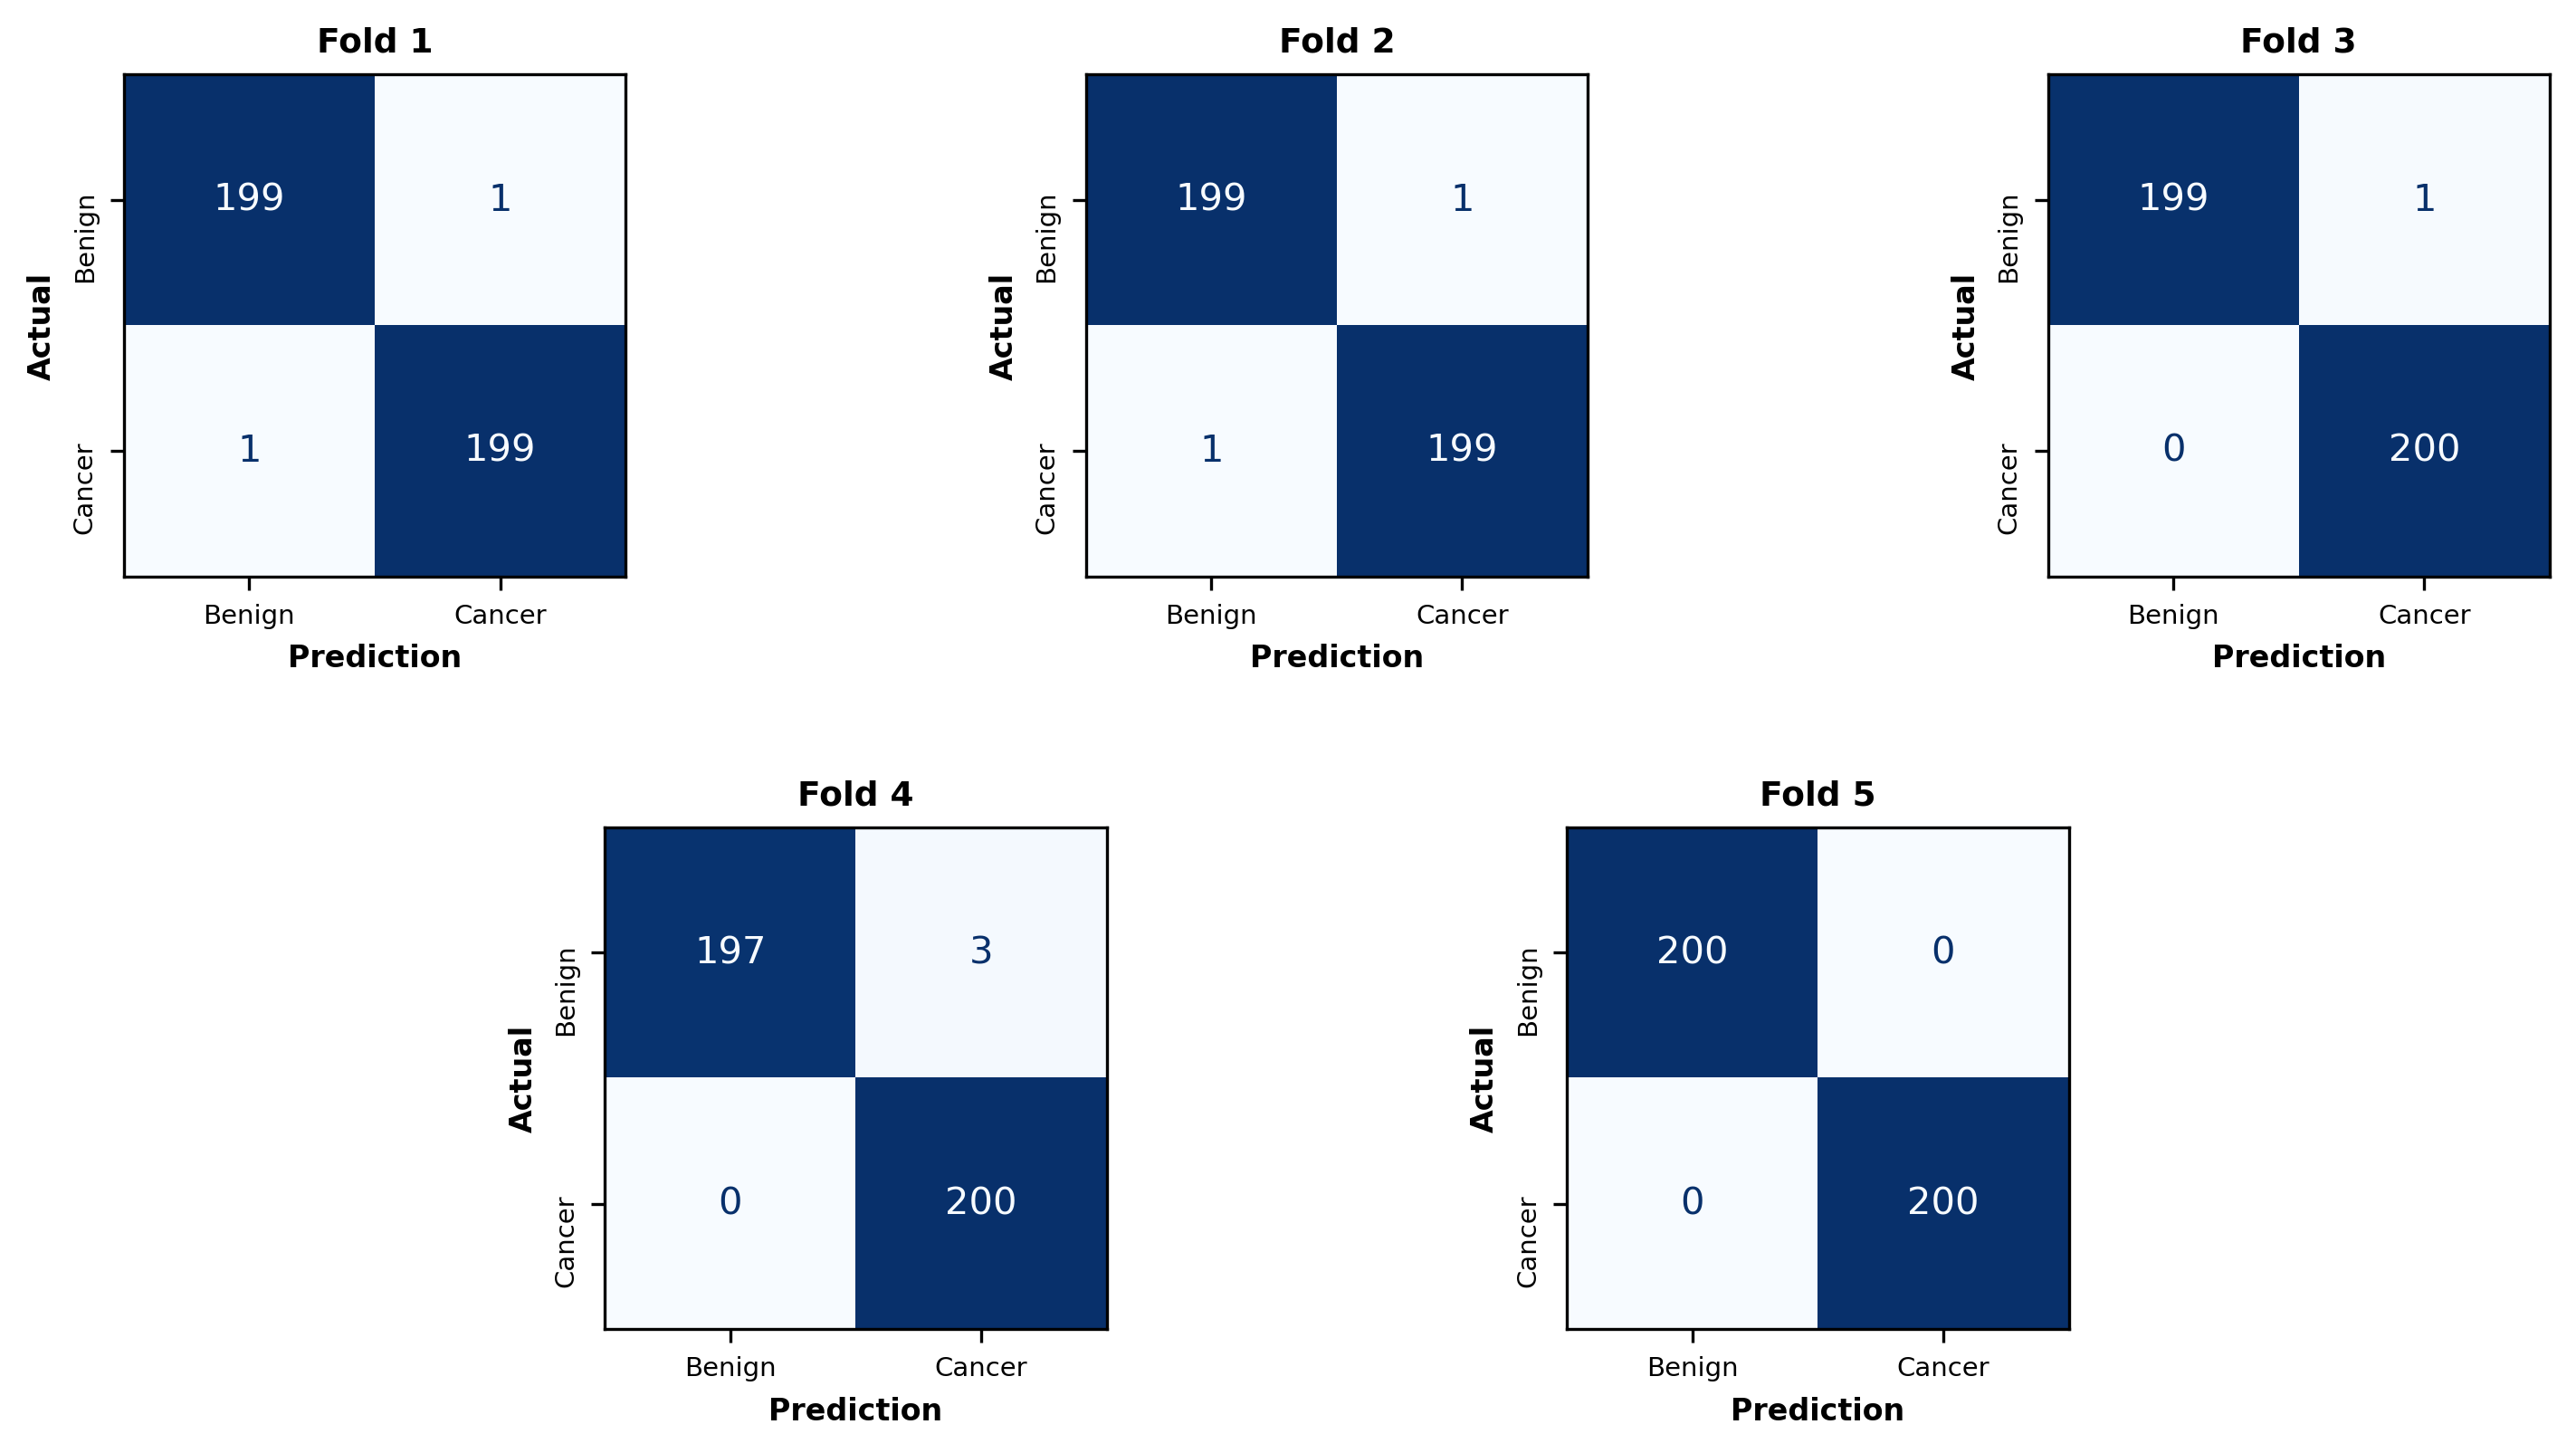

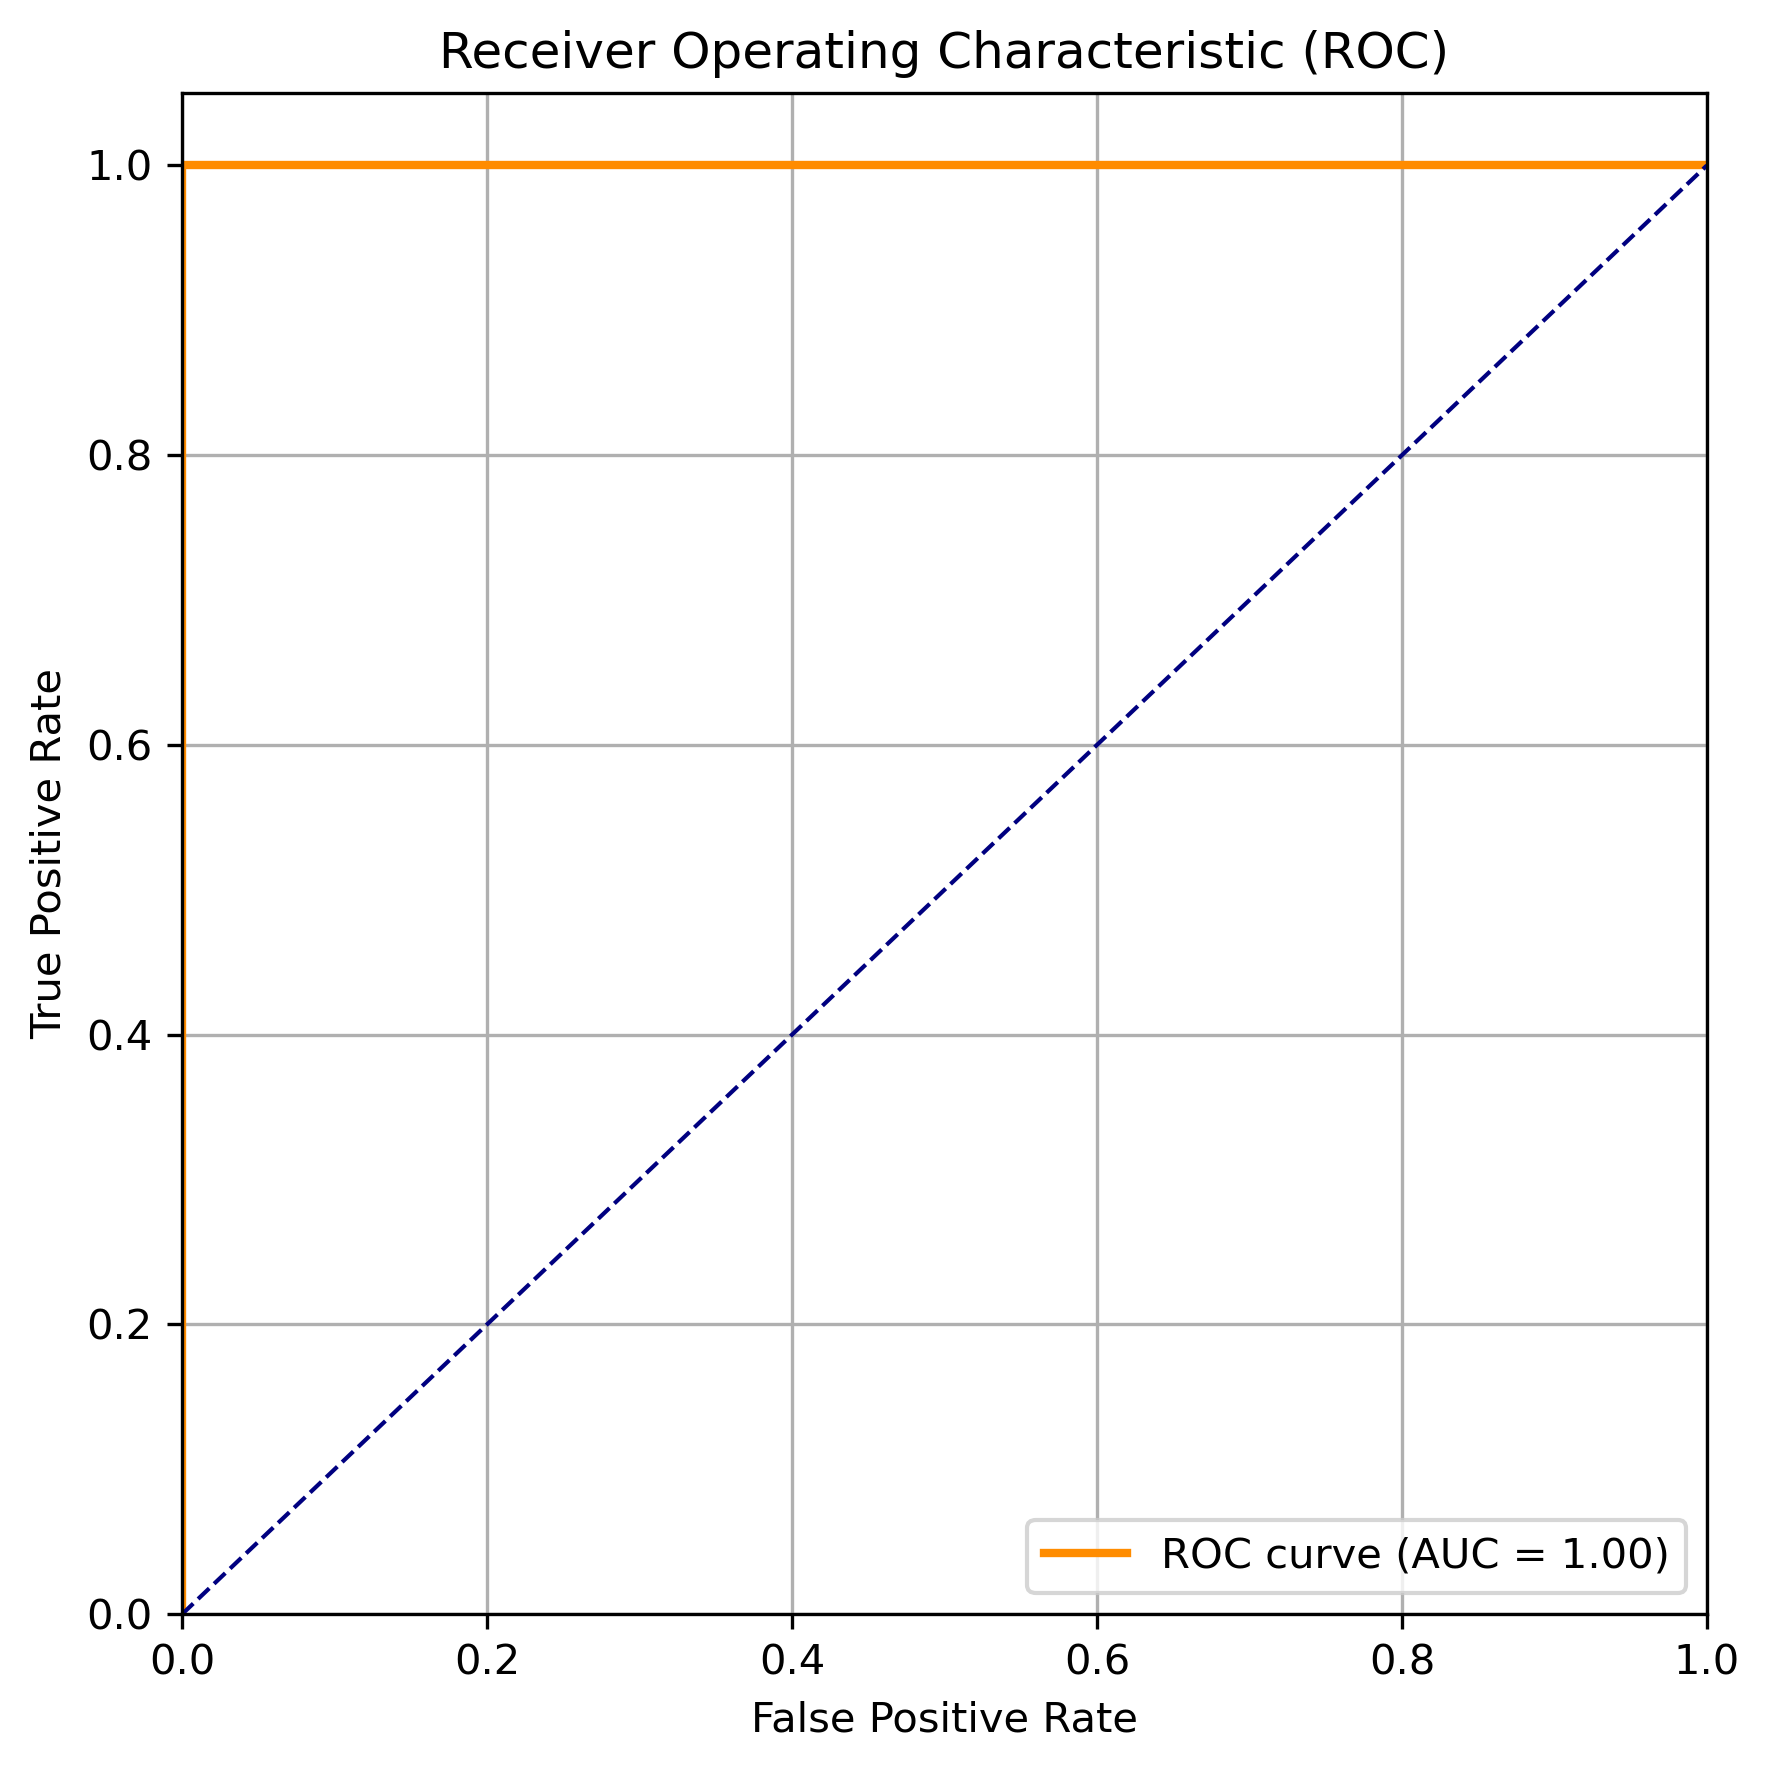

Permutation Test Results:
  Original Model Accuracy: 0.9960
  Mean Permuted Accuracy: 0.5010
  p-value: 0.0099
  The model significantly outperforms random chance (p < 0.05).


In [21]:
labels_file_path = os.path.join(MAIN_PIPLINE_DIR, 'training_data_labels.csv')
features_file_path = os.path.join(MAIN_PIPLINE_DIR, 'training_data_reduced_features.csv')

model_file_prefix = os.path.join(MODELS_DIR, 'rfc_model_5F_CV_')
report_file = os.path.join(REPORTS_DIR, 'CV_report.txt')

cross_validate_model(features_file_path, labels_file_path, model_file_prefix, report_file,
    perm=True, num_splits=5, n_permutations=100)